# Part of Speech
##### Autors: Josep de Cid & Gonzalo Recio

## Introduction

Using the Treebank corpus, we train HMM, TnT, Perceptron and CRF models using the first 500, 1000, 1500, 2000, 2500 and 3000 sentences.

In [1]:
import nltk
import dill
import time
import matplotlib.pyplot as plt

from datetime import timedelta

nltk.download('treebank')

from nltk.tag.hmm import HiddenMarkovModelTrainer
from nltk.tag.tnt import TnT
from nltk.tag.perceptron import PerceptronTagger
from nltk.tag import CRFTagger

from nltk.corpus import treebank

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/josepdecidrodriguez/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


We are going to store each model in a 2-levels dictionary with model-data_size keys, *e.g. models['HMM'][500]*

In [2]:
models = {'HMM': {}, 'TnT': {}, 'Perceptron': {}, 'CRF': {}}
DATA_SIZES = list(range(500, 3001, 500))

We will also store each trained model objects into files to avoid training it every time if required in next executions, into a folder called *models*.

In [3]:
!mkdir models

mkdir: models: File exists


## Models - Training

For each model we are going to update the models dictionary and calculate the training time for later analysis and conclusions extraction.

### HMM

In [4]:
!mkdir models/HMM

for data_size in DATA_SIZES:
    train_data = treebank.tagged_sents()[:data_size]
    
    ts = time.time()
    
    trainer = HiddenMarkovModelTrainer()
    models['HMM'][data_size] = trainer.train_supervised(train_data)
    
    print(f'HMM with train data size {data_size:4} took {time.time() - ts:.6f}s')
    
    with open(f'models/HMM/{data_size}', mode='wb') as f:
        dill.dump(models['HMM'][data_size], f)

mkdir: models/HMM: File exists
HMM with train data size  500 took 0.302398s
HMM with train data size 1000 took 0.480829s
HMM with train data size 1500 took 0.947692s
HMM with train data size 2000 took 0.924446s
HMM with train data size 2500 took 1.215186s
HMM with train data size 3000 took 1.428900s


### TnT

In [5]:
!mkdir models/TnT

for data_size in DATA_SIZES:
    train_data = treebank.tagged_sents()[:data_size]
    
    ts = time.time()
    
    models['TnT'][data_size] = TnT()
    models['TnT'][data_size].train(train_data)
    
    print(f'TnT with train data size {data_size:4} took {time.time() - ts:.6f}s')
    
    with open(f'models/TnT/{data_size}', mode='wb') as f:
        dill.dump(models['TnT'][data_size], f)

mkdir: models/TnT: File exists
TnT with train data size  500 took 0.284523s
TnT with train data size 1000 took 0.592298s
TnT with train data size 1500 took 0.933077s
TnT with train data size 2000 took 1.173903s
TnT with train data size 2500 took 1.516895s
TnT with train data size 3000 took 1.774056s


### Perceptron

In [6]:
!mkdir models/Perceptron

for data_size in DATA_SIZES:
    train_data = treebank.tagged_sents()[:data_size]
    
    ts = time.time()
    
    models['Perceptron'][data_size] = PerceptronTagger(load=False)
    models['Perceptron'][data_size].train(train_data)
    
    print(f'Perceptron with train data size {data_size:4} took {time.time() - ts:.6f}s')
    
    with open(f'models/Perceptron/{data_size}', mode='wb') as f:
        dill.dump(models['Perceptron'][data_size], f)

mkdir: models/Perceptron: File exists
Perceptron with train data size  500 took 3.418736s
Perceptron with train data size 1000 took 6.794415s
Perceptron with train data size 1500 took 9.867890s
Perceptron with train data size 2000 took 13.265914s
Perceptron with train data size 2500 took 16.186647s
Perceptron with train data size 3000 took 20.553498s


### CRF

In [7]:
!mkdir models/CRF

for data_size in DATA_SIZES:
    train_data = treebank.tagged_sents()[:data_size]
    
    ts = time.time()
    
    models['CRF'][data_size] = CRFTagger()
    models['CRF'][data_size].train(train_data, f'models/CRF/{data_size}')
    
    print(f'CRF with train data size {data_size:4} took {time.time() - ts:.6f}s')

mkdir: models/CRF: File exists
CRF with train data size  500 took 2.776139s
CRF with train data size 1000 took 7.426866s
CRF with train data size 1500 took 12.650785s
CRF with train data size 2000 took 19.549661s
CRF with train data size 2500 took 27.649578s
CRF with train data size 3000 took 33.616499s


## Models - Evaluation

Let's evaluate all the 24 generated models with the sentences from 3001.

In [8]:
test_data = treebank.tagged_sents()[3001:]
accuracies = {'HMM': {}, 'TnT': {}, 'Perceptron': {}, 'CRF': {}}

for name, model_sizes in models.items():
    for size, model in model_sizes.items():
        ts = time.time()
        accuracies[name][size] = model.evaluate(test_data)
        print(f'{name:10} with data size {size:4} accuracy = {accuracies[name][size]:.6f} ' +
              f'({time.time() - ts:.6f}s)')

HMM        with data size  500 accuracy = 0.172810 (7.318520s)
HMM        with data size 1000 accuracy = 0.220691 (7.224256s)
HMM        with data size 1500 accuracy = 0.261614 (7.470476s)
HMM        with data size 2000 accuracy = 0.304395 (8.973773s)
HMM        with data size 2500 accuracy = 0.335206 (20.177459s)
HMM        with data size 3000 accuracy = 0.368567 (8.534201s)
TnT        with data size  500 accuracy = 0.747461 (16.375640s)
TnT        with data size 1000 accuracy = 0.796336 (55.839083s)
TnT        with data size 1500 accuracy = 0.827536 (92.499360s)
TnT        with data size 2000 accuracy = 0.848537 (85.967405s)
TnT        with data size 2500 accuracy = 0.862365 (92.157457s)
TnT        with data size 3000 accuracy = 0.875632 (122.106096s)
Perceptron with data size  500 accuracy = 0.910937 (2.832235s)
Perceptron with data size 1000 accuracy = 0.933624 (1.917803s)
Perceptron with data size 1500 accuracy = 0.941792 (1.882856s)
Perceptron with data size 2000 accuracy = 0.950

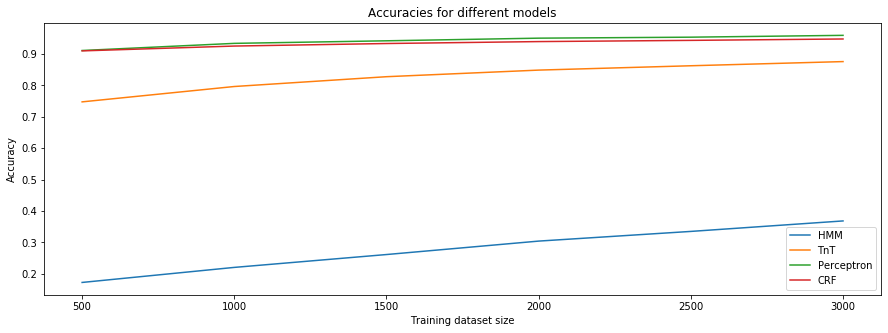

In [9]:
plt.figure(figsize=(15, 5))
plt.xlabel('Training dataset size')
plt.ylabel('Accuracy')
plt.title('Accuracies for different models')

for name, model_sizes in accuracies.items():
    x, y = list(zip(*model_sizes.items()))
    plt.plot(x, y, label=name)
    
plt.legend()
plt.show()

## Conclusions

HMM is the fastest model to train, but has the worst performance in terms of accuracy, barely reaching an accuracy of 0.4 with the maximum train data size.

The Perceptron and CRF models have quite a similar performance, reaching with the smallest train data size an accuracy over 0.9, being the Perceptron slightly better in terms of accuracy, obtaining ~0.96, against the ~0.95 of the CRF, being also the Perceptron about 1.5x faster to train than the CRF. Both are relatively fast to execute.

TnT also does a good job, reaching a bit lower accuracy, but training 10x faster than the Perceptron, having a similar training time compared to the HMM, but it's evaluation time is much greater than any of the other models.

Concluding, we would choose, the *Perceptron*, as it gives the highest accuracy without taking into account the ammount of time required for training the model, which is done only once, and being very fast to evaluate.